<a href="https://colab.research.google.com/github/juliocemendozza3-netizen/CRC-MONITOREO-DIARIO-/blob/main/CRC_OBSERVACION_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q git+https://github.com/openai/whisper.git yt-dlp moviepy

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
import yt_dlp

url = "https://www.youtube.com/watch?v=KQd7--8acuM&t=3s"

ydl_opts = {
    'format': 'mp4',
    'outtmpl': 'video.mp4',
    'quiet': True
}

with yt_dlp.YoutubeDL(ydl_opts) as ydl:
    ydl.download([url])

print("✅ Video descargado")

✅ Video descargado


In [4]:
from moviepy.editor import VideoFileClip

clip = VideoFileClip("video.mp4").subclip(0, 300)  # primeros 5 min
clip.write_videofile("video_corto.mp4", verbose=False, logger=None)

archivo = "video_corto.mp4"

print("✅ Video recortado")

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':



✅ Video recortado


In [5]:
import whisper

model = whisper.load_model("tiny")  # rápido para piloto

100%|██████████████████████████████████████| 72.1M/72.1M [00:00<00:00, 104MiB/s]


In [6]:
resultado = model.transcribe(archivo)
segmentos = resultado["segments"]

print(f"✅ Segmentos detectados: {len(segmentos)}")

  warnings.warn("FP16 is not supported on CPU; using FP32 instead")



✅ Segmentos detectados: 137


In [7]:
CANDIDATOS = {
    "clara lopez": ["clara eugenia lopez obregon", "clara lopez"],
    "oscar lizcano": ["oscar mauricio lizcano arango", "oscar lizcano", "lizcano"],
    "raul botero": ["raul santiago botero jaramillo", "raul botero", "botero"],
    "miguel uribe": ["miguel uribe londono", "miguel uribe", "uribe"],
    "sondra macollins": ["sondra macollins garvin pinto"],
    "ivan cepeda": ["ivan cepeda castro", "ivan cepeda", "cepeda"],
    "abelardo de la espriella": ["abelardo gabriel de la espriella", "de la espriella"],
    "claudia lopez": ["claudia nayibe lopez hernandez", "claudia lopez"],
    "paloma valencia": ["paloma susana valencia laserna", "paloma valencia", "valencia"],
    "sergio fajardo": ["sergio fajardo valderrama", "sergio fajardo", "fajardo"],
    "roy barreras": ["roy leonardo barreras montealegre", "roy barreras", "barreras"]
}

In [8]:
def detectar_candidatos(texto):
    texto = texto.lower()
    encontrados = []

    for candidato, alias in CANDIDATOS.items():
        for a in alias:
            if a in texto:
                encontrados.append(candidato)
                break

    return encontrados

In [9]:
tiempos = {}

for seg in segmentos:
    texto = seg["text"]
    duracion = seg["end"] - seg["start"]

    candidatos = detectar_candidatos(texto)

    for c in candidatos:
        tiempos[c] = tiempos.get(c, 0) + duracion

print("📊 RESULTADOS:")
for k, v in tiempos.items():
    print(k, ":", round(v, 2), "segundos")

📊 RESULTADOS:
sergio fajardo : 0.76 segundos
paloma valencia : 2.0 segundos


In [15]:
for seg in segmentos:
    candidatos = detectar_candidatos(seg["text"])
    if candidatos:
        print(f"{seg['start']:.1f}-{seg['end']:.1f}")
        print(seg["text"])
        print("→", candidatos)
        print("-"*50)

122.5-123.2
 geofajardo, pues de la
→ ['sergio fajardo']
--------------------------------------------------
188.6-190.6
 Cartagena Paloma Valencia del
→ ['paloma valencia']
--------------------------------------------------


In [10]:
import pandas as pd

df = pd.DataFrame(list(tiempos.items()), columns=["candidato", "tiempo"])

df.sort_values(by="tiempo", ascending=False)

,candidato,tiempo
1,paloma valencia,2.00
0,sergio fajardo,0.76


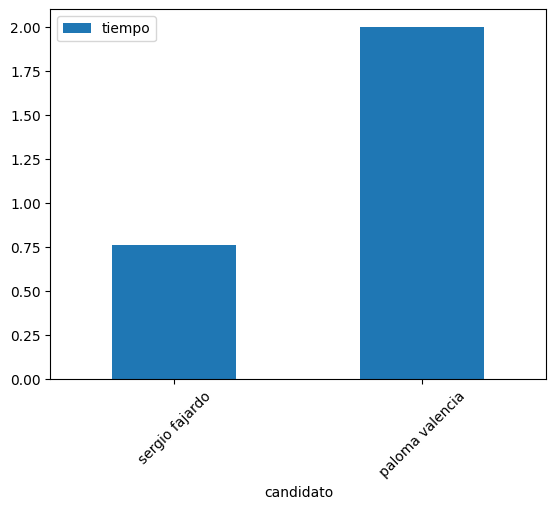

In [14]:
import matplotlib.pyplot as plt

df.plot(kind="bar", x="candidato", y="tiempo")
plt.xticks(rotation=45)
plt.show()

In [13]:
for seg in segmentos:
    candidatos = detectar_candidatos(seg["text"])
    if candidatos:
        print(f"{seg['start']:.1f}-{seg['end']:.1f}: {seg['text']} → {candidatos}")

122.5-123.2:  geofajardo, pues de la → ['sergio fajardo']
188.6-190.6:  Cartagena Paloma Valencia del → ['paloma valencia']


In [18]:
!pip install transformers

In [19]:
from transformers import pipeline

sentiment = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment")

def clasificar_tono(texto):
    res = sentiment(texto)[0]
    estrellas = int(res["label"][0])

    if estrellas <= 2:
        return "negativo"
    elif estrellas == 3:
        return "neutral"
    else:
        return "positivo"

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [21]:
import json
from datetime import datetime

log = {
    "fecha": str(datetime.now()),
    "video": archivo,
    "total_segmentos": len(segmentos),
    "resultados": tiempos
}

with open("log_auditoria.json", "w") as f:
    json.dump(log, f, indent=4)

print("✅ Log de auditoría guardado")

✅ Log de auditoría guardado


In [23]:
resultados_totales = []

for seg in segmentos:
    candidatos = detectar_candidatos(seg["text"])
    tono = clasificar_tono(seg["text"])

    resultados_totales.append({
        "texto": seg["text"],
        "inicio": seg["start"],
        "fin": seg["end"],
        "candidatos": candidatos,
        "tono": tono
    })

In [27]:
{
  "fecha": "2026-04-26",
  "video": "video_corto.mp4",
  "total_segmentos": 120,
  "resultados": [
    {
      "texto": "El candidato Fajardo...",
      "candidatos": ["sergio fajardo"],
      "tono": "positivo"
    }
  ]
}

{'fecha': '2026-04-26',
 'video': 'video_corto.mp4',
 'total_segmentos': 120,
 'resultados': [{'texto': 'El candidato Fajardo...',
   'candidatos': ['sergio fajardo'],
   'tono': 'positivo'}]}

In [28]:
import numpy as np

valores = np.array(list(tiempos.values()))

if len(valores) > 0:
    promedio = np.mean(valores)
    equidad = 1 - (np.sum(np.abs(valores - promedio)) / np.sum(valores))
else:
    equidad = 0

print("Equidad de tiempo:", equidad)

Equidad de tiempo: 0.5507246376811621


In [30]:
positive_count = 0
negative_count = 0
for r in resultados_totales:
    if r["tono"] == "positivo":
        positive_count += 1
    elif r["tono"] == "negativo":
        negative_count += 1

pos = positive_count
neg = negative_count

if (pos + neg) > 0:
    balance = 1 - abs(pos - neg) / (pos + neg)
else:
    balance = 1

print("Balance de tono:", balance)

Balance de tono: 0.6724137931034483


In [31]:
total_candidatos = len(CANDIDATOS)
presentes = len(tiempos)

presencia = presentes / total_candidatos

print("Presencia:", presencia)

Presencia: 0.18181818181818182


In [33]:
pluralismo = (equidad + balance + presencia) / 3

print("Índice de Pluralismo:", pluralismo)

Índice de Pluralismo: 0.4683188708675974


In [35]:
if pluralismo >= 0.8:
    estado = "🟢 Alto pluralismo"
elif pluralismo >= 0.6:
    estado = "🟡 Aceptable"
elif pluralismo >= 0.4:
    estado = "🟠 Riesgo"
else:
    estado = "🔴 Crítico"

print("Estado:", estado)

Estado: 🟠 Riesgo
